In [21]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
protein_file = PROJECT_ROOT / "data/raw/proteomics/PXD037393/40478_2022_1455_MOESM1_ESM.xlsx"
metadata_file = PROJECT_ROOT / "data/metadata/proteomics/PXD037393/40478_2022_1455_MOESM3_ESM.xlsx"

In [5]:
print("Protein file exists:", protein_file.exists(), protein_file.stat().st_size if protein_file.exists() else "missing")

Protein file exists: True 2193457


In [6]:
print("Metadata file exists:", metadata_file.exists(), metadata_file.stat().st_size if metadata_file.exists() else "missing")

Metadata file exists: True 16260


In [8]:
protein_xls = pd.ExcelFile(protein_file)
metadata_xls = pd.ExcelFile(metadata_file)

In [9]:
print("\nProtein workbook sheets:")
print(protein_xls.sheet_names)


Protein workbook sheets:
['Cover Page', 'RAW', 'Control norm_Ratiometric data', 'Z-scores']


In [10]:
print("\nMetadata workbook sheets:")
print(metadata_xls.sheet_names)


Metadata workbook sheets:
['Cover Page', 'Supplementary Table 1']


In [15]:
raw = pd.read_excel(protein_file, sheet_name="RAW")
ratio = pd.read_excel(protein_file, sheet_name="Control norm_Ratiometric data")
zscore = pd.read_excel(protein_file, sheet_name="Z-scores")
cohort = pd.read_excel(metadata_file, sheet_name="Supplementary Table 1")

In [16]:
for name, table in {
    "raw": raw,
    "ratio": ratio,
    "zscore": zscore,
    "cohort": cohort,
}.items():
    print(name, table.shape)
    display(table.head())

raw (5351, 16)


,Majority protein IDs,Protein names,Gene names,Fasta headers,Number of proteins,Unique peptides,Reporter intensity corrected Ctrl BA9,Reporter intensity corrected Ctrl BA4,Reporter intensity corrected ALS BA9,Reporter intensity corrected ALS BA4,Reporter intensity corrected ALSnoci BA9,Reporter intensity corrected ALSnoci BA4,Reporter intensity corrected ALSci BA9,Reporter intensity corrected ALSci BA4,Reporter intensity corrected ALS BA9 C9-,Reporter intensity corrected ALS BA9 C9+
0,P04217,Alpha-1B-glycoprotein,A1BG,sp|P04217|A1BG_HUMAN Alpha-1B-glycoprotein OS=...,2.0,5.0,40011.0,40507.0,53187.0,44698.0,51115.0,50331.0,47863.0,39724.0,48729.0,50198
1,P01023,Alpha-2-macroglobulin,A2M,sp|P01023|A2MG_HUMAN Alpha-2-macroglobulin OS=...,3.0,34.0,232800.0,177570.0,239410.0,210160.0,252400.0,246810.0,230410.0,195130.0,227080.0,242160
2,Q86V21,Acetoacetyl-CoA synthetase,AACS,sp|Q86V21|AACS_HUMAN Acetoacetyl-CoA synthetas...,1.0,6.0,88756.0,55739.0,77812.0,57489.0,75268.0,62577.0,75692.0,59439.0,75366.0,81684
3,Q6PD74,Alpha- and gamma-adaptin-binding protein p34,AAGAB,sp|Q6PD74|AAGAB_HUMAN Alpha- and gamma-adaptin...,1.0,3.0,32604.0,23308.0,35110.0,25648.0,31675.0,29512.0,36553.0,27408.0,30518.0,36851
4,Q2M2I8,AP2-associated protein kinase 1,AAK1,sp|Q2M2I8|AAK1_HUMAN AP2-associated protein ki...,1.0,31.0,341440.0,237840.0,330670.0,259150.0,327560.0,281140.0,333340.0,249290.0,308140.0,375400


ratio (5348, 9)


,Gene ID,ALS BA9,ALS BA4,ALSnoci BA9,ALSnoci BA4,ALSci BA9,ALSci BA4,ALS BA9 C9-,ALS BA9 C9+
0,A1BG,1.362937,1.011533,1.386655,1.075710,1.223387,0.909339,1.354672,1.224956
1,A2M,1.054409,1.084932,1.176809,1.203325,1.012189,1.018961,1.084981,1.015624
2,AACS,0.898873,0.945470,0.920475,0.971953,0.872159,0.988815,0.944504,0.898572
3,AAGAB,1.104103,1.008720,1.054497,1.096184,1.146556,1.090373,1.041145,1.103550
4,AAK1,0.992956,0.998823,1.041300,1.023358,0.998427,0.971903,1.003829,1.073479


zscore (5348, 10)


,Uniprot,Gene ID,ALS BA9,ALS BA4,ALSnoci BA9,ALSnoci BA4,ALSci BA9,ALSci BA4,ALS BA9 C9-,ALS BA9 C9+
0,P04217,A1BG,2.981752,0.038013,2.938466,0.573906,1.884599,-0.817181,2.642487,1.635912
1,P01023,A2M,0.477135,0.658394,1.452403,1.494357,0.092592,0.105302,0.694637,0.149010
2,Q86V21,AACS,-1.080244,-0.560140,-0.772518,-0.258867,-1.315415,-0.138088,-0.521972,-0.822558
3,Q6PD74,AAGAB,0.926542,0.013349,0.458519,0.728705,1.271275,0.654293,0.332780,0.807786
4,Q2M2I8,AAK1,-0.108848,-0.073975,0.344466,0.164273,-0.036858,-0.277909,0.012527,0.588580


cohort (29, 13)


,Unnamed: 0,Brain Bank ID,PMI (hrs),Age at death (years),Disease Duration (months),Region of onset,ECAS Total,ECAS ALS Specific,Gender (M/F),C9ORF72 status,Cognitive Status,pTDP43 BA4,pTDP43 BA9
0,Control,BBN001.28406,72,79,NaN,NaN,NaN,NaN,M,NaN,Control,no,no
1,NaN,BBN001.28793,72,79,NaN,NaN,NaN,NaN,F,NaN,Control,no,no
2,NaN,BBN001.28794,72,79,NaN,NaN,NaN,NaN,F,NaN,Control,no,no
3,NaN,BBN001.26495,39,78,NaN,NaN,NaN,NaN,M,NaN,Control,no,no
4,NaN,BBN001.28797,57,79,NaN,NaN,NaN,NaN,M,NaN,Control,no,no


In [17]:
display(ratio.isna().mean().sort_values(ascending=False).head(20))
display(zscore.isna().mean().sort_values(ascending=False).head(20))

Gene ID         0.0
ALS BA9         0.0
ALS BA4         0.0
ALSnoci BA9     0.0
ALSnoci BA4     0.0
ALSci BA9       0.0
ALSci BA4       0.0
ALS BA9 C9-     0.0
ALS BA9 C9+     0.0
dtype: float64

Uniprot         0.0
Gene ID         0.0
ALS BA9         0.0
ALS BA4         0.0
ALSnoci BA9     0.0
ALSnoci BA4     0.0
ALSci BA9       0.0
ALSci BA4       0.0
ALS BA9 C9-     0.0
ALS BA9 C9+     0.0
dtype: float64

In [18]:
display(cohort["Cognitive Status "].value_counts(dropna=False))
display(cohort["C9ORF72 status"].value_counts(dropna=False))
display(cohort["Gender (M/F) "].value_counts(dropna=False))

Cognitive Status 
unimpaired    10
Control        9
impaired       5
Impaired       3
Control        1
Control        1
Name: count, dtype: int64

C9ORF72 status
NEGATIVE        12
NaN             11
C9ORF72 +ve      5
C9ORF72 +ve      1
Name: count, dtype: int64

Gender (M/F) 
M     17
F     12
Name: count, dtype: int64

In [19]:
key_genes = [
    "C9ORF72", "SMCR8", "WDR41",
    "RB1CC1", "ULK1", "ULK2", "ATG13", "ATG101",
    "TBK1", "CGAS", "STING1", "TMEM173", "IRF3",
    "SQSTM1", "OPTN",
]

available = set(zscore["Gene ID"].astype(str).str.upper())
present = [gene for gene in key_genes if gene.upper() in available]
missing = [gene for gene in key_genes if gene.upper() not in available]

print("Present:", present)
print("Missing:", missing)

Present: ['C9ORF72', 'SMCR8', 'WDR41', 'RB1CC1', 'ULK1', 'ATG13', 'ATG101', 'TBK1', 'SQSTM1', 'OPTN']
Missing: ['ULK2', 'CGAS', 'STING1', 'TMEM173', 'IRF3']


In [20]:
key_present = [gene for gene in key_genes if gene.upper() in available]

plot_df = (
    zscore[zscore["Gene ID"].astype(str).str.upper().isin([g.upper() for g in key_present])]
    .set_index("Gene ID")
    .drop(columns=["Uniprot"], errors="ignore")
    .T
)

display(plot_df)

Gene ID,ATG101,ATG13,C9orf72,OPTN,RB1CC1,SMCR8,SQSTM1,TBK1,ULK1,WDR41
ALS BA9,0.262502,-0.182193,-0.531916,-0.103082,0.381392,-1.446318,1.117520,-0.315792,0.136854,-0.954950
ALS BA4,-0.075794,0.239665,-0.444379,-0.271336,0.056176,-1.571462,1.022556,-0.214329,0.121206,-0.957321
ALSnoci BA9,0.074674,-0.204535,-0.927489,0.032821,0.446751,-0.877995,1.286830,0.120894,0.468742,-0.378897
ALSnoci BA4,0.692752,0.009460,-0.581091,0.062798,0.427328,-0.472778,0.800337,-0.048673,0.218119,-0.600287
ALSci BA9,0.298590,-0.098139,-0.894360,-0.518565,0.357713,-1.379346,0.972819,-0.390419,-0.126298,-0.977289
ALSci BA4,0.686043,-0.059373,-0.943692,-0.357886,-0.112946,-1.156701,1.032650,-0.030004,-0.310422,-0.344033
ALS BA9 C9-,0.467343,0.133202,0.216948,0.034526,0.211950,-0.367838,1.406027,0.020182,0.617195,-0.411305
ALS BA9 C9+,0.631120,-0.064780,-1.081247,-0.245870,0.613154,-1.647444,1.111460,-0.550471,0.690906,-0.851105


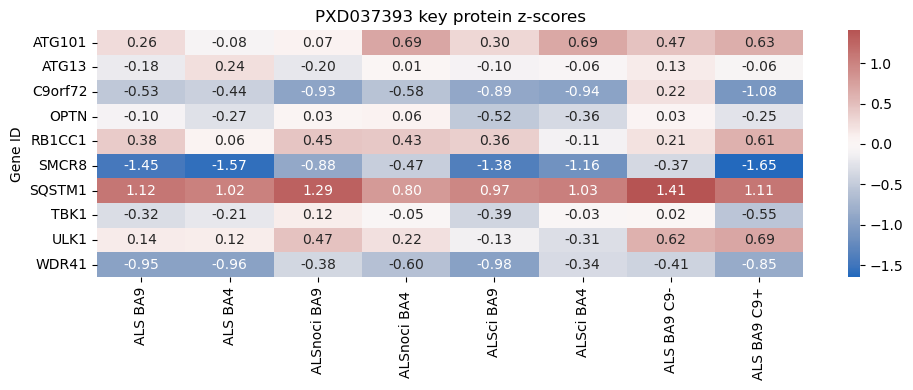

In [22]:
plt.figure(figsize=(10, max(4, 0.35 * len(key_present))))
sns.heatmap(plot_df.T, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("PXD037393 key protein z-scores")
plt.tight_layout()
plt.show()